Copyright (C) 2025  Diarmuid

This program is free software: you can redistribute it and/or modify\
it under the terms of the GNU General Public License as published by\
the Free Software Foundation, either version 3 of the License, or\
(at your option) any later version.

This program is distributed in the hope that it will be useful,\
but WITHOUT ANY WARRANTY; without even the implied warranty of\
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the\
GNU General Public License for more details.

You should have received a copy of the GNU General Public License\
along with this program.  If not, see <https://www.gnu.org/licenses/>.

----------------------------------------------------------------------

Author: Diarmuid O'Neill\
Student Number: C00282898\
Date: 12/02/2026\
Brief Description:
This notebook aims to use a convolutional neural network to identify the species of a butterfly given its image. 

In [3]:
# Needed imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

We start by importing the data. This data is already split into a training dataset consisting of 224px x 224px .jpg images and their corresponding species labels. The test set consists of unseen .jpg images with no species labels and thus cannot be used to evaluate the models performance however, with over 6000 examples the training set has more than enough data to work with. It can simply be split into training and validation sets.

In [4]:
trainingDataset = pd.read_csv("Training_set.csv")
trainingDataset.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


In [5]:
testDataset = pd.read_csv("Testing_set.csv")
testDataset.head()

,filename
0,Image_1.jpg
1,Image_2.jpg
2,Image_3.jpg
3,Image_4.jpg
4,Image_5.jpg


Here we split the training data into training and validation sets. 20% of the data will be used as a validation set and 80% will be used for training the model.

In [6]:
# Splitting the training data into the training set and validation set
training_df, validation_df = train_test_split(
    trainingDataset,
    test_size=0.2,
    random_state=42,
    stratify=trainingDataset["label"]
)

Data generators are used to pull data in from their respective files in small batches as image data uses a lot of memory and there are a lot of images. We use a generator for each dataset. img_size defines the size of each image in p;ixels and batch_size is how many images we are pulling in at a time.

In [7]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1.0 / 255)
val_datagen   = ImageDataGenerator(rescale=1.0 / 255)
test_datagen  = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=training_df,
    directory="train",
    x_col="filename",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=validation_df,
    directory="train",
    x_col="filename",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=testDataset,
    directory="test",
    x_col="filename",
    y_col=None,
    target_size=img_size,
    batch_size=batch_size,
    class_mode=None,
    shuffle=False
)

Found 5199 validated image filenames belonging to 75 classes.
Found 1300 validated image filenames belonging to 75 classes.
Found 2786 validated image filenames.


Next we build our model (see below). This convolutional neural network consists of three blocks. Block one performs a convolution using 32, 3 x 3 filters on each image. Then, on the next line pooling is performed using a 2 x 2 grid. This reduces the dimensions of the feature maps by half, which reduces computation and helps prevent overfitting. Using the output from block one, the same process occurs again in block two. This time 64 filters are used. The purpose of this layer is to combine the features learned in block one to learn more complex features. Block three does the same thing again to learn even more complex features this time with 128 filters. Next the output is flattened into a one dimensional array and a dense layer with relu activation learns how to combine all of the learned features. Dropout turns off 50% of the neurons to reduce overfitting. A final dense layer uses the softmax activation function to output a probability score per species.

In [8]:
# Dictionary mapping each species to a number
# eg. {"ADONIS": 0, "MONARCH": 1, ...}
number_of_classes = len(train_generator.class_indices)

# Building the model, Each block learns more complex features
# The activation function "relu" sets any negative values to zero
model = keras.Sequential([
    
    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(*img_size, 3)),
    layers.MaxPooling2D(2, 2),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    # Classifier head
    layers.Flatten(),
    layers.Dense(128, activation="relu"), # Takes all learned features and learns how to combine them
    layers.Dropout(0.5), # Reduces overfitting
    layers.Dense(number_of_classes, activation="softmax") # Outputs a probability score per species
])

model.summary()

C:\Users\Diarmuid\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 75)                  │           9,675 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,178,635 (42.64 MB)

 Trainable params: 11,178,635 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

After building the model we compile it. The optimizer parameter is the algorithm used to adjust weights at each step. The loss parameter tells the model what loss function to use to measure how wrong predictions are. The metric parameter is simply the metric that is tracked while the model is being trained.

In [9]:
model.compile(
    optimizer="adam", # Algorithm to adjust weights
    loss="categorical_crossentropy", # Loss function, measures how wrong a prediction is
    metrics=["accuracy"] # Metric that is tracked to track progress
)

Next we train the model over 20 epochs (This takes a long time). train_generator pulls in the training data and val_generator pulls in the validation data.

In [10]:
trainedModel=model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 332ms/step - accuracy: 0.0452 - loss: 4.1795 - val_accuracy: 0.1285 - val_loss: 3.7121
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 209ms/step - accuracy: 0.1679 - loss: 3.4301 - val_accuracy: 0.3631 - val_loss: 2.7290
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 209ms/step - accuracy: 0.3278 - loss: 2.6004 - val_accuracy: 0.4385 - val_loss: 2.2355
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 209ms/step - accuracy: 0.4724 - loss: 1.9136 - val_accuracy: 0.4792 - val_loss: 1.9860
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 208ms/step - accuracy: 0.5705 - loss: 1.5071 - val_accuracy: 0.4885 - val_loss: 1.9775
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 209ms/step - accuracy: 0.6476 - loss: 1.2004 - val_accuracy: 0.5038 - val_loss: 1.9417
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 206ms/step - accuracy: 0.7113 - loss: 0.9351 - val_accuracy: 0.5092 - val_loss: 1.9357
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 207ms/step - accuracy: 0.7657 - loss: 0

While we can't evaluate the model on the unseen test data (as there is no species labels), this is how we would predict some examples from the validation set.

In [18]:
predictions = model.predict(val_generator)
predicted_indices = np.argmax(predictions, axis=1)

index_to_class = {v: k for k, v in train_generator.class_indices.items()}
predicted_labels = [index_to_class[i] for i in predicted_indices]

val_generator.reset()
true_indices = val_generator.classes
true_labels = [index_to_class[i] for i in true_indices]

results = pd.DataFrame({
    "filename": val_generator.filenames,
    "true_label": true_labels,
    "predicted_label": predicted_labels
})

print(results.head(10))

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step
         filename          true_label           predicted_label
0  Image_4100.jpg       BECKERS WHITE         TROPICAL LEAFWING
1  Image_6404.jpg         BLUE MORPHO        CHECQUERED SKIPPER
2  Image_5730.jpg       CRIMSON PATCH  BANDED ORANGE HELICONIAN
3  Image_1234.jpg          PAPER KITE        TWO BARRED FLASHER
4   Image_657.jpg              ULYSES       YELLOW SWALLOW TAIL
5  Image_1276.jpg  CLODIUS PARNASSIAN                 GREAT JAY
6  Image_1657.jpg   TROPICAL LEAFWING             DANAID EGGFLY
7  Image_3504.jpg             MONARCH         TROPICAL LEAFWING
8   Image_603.jpg         RED POSTMAN           ZEBRA LONG WING
9  Image_4613.jpg           METALMARK    MILBERTS TORTOISESHELL


Now we will look at how the model performed on the training and validation sets that we split up earlier. The below accuracy graph shows that validation accuracy plateaus after about four epochs and training accuracy keeps climbing. Also in the loss graph you can see validation loss plateaus after about epoch four while training loss continues to plummet. This seems to indicate that the model is overfitting using the training data and causes it to perform more poorly on the validation set.

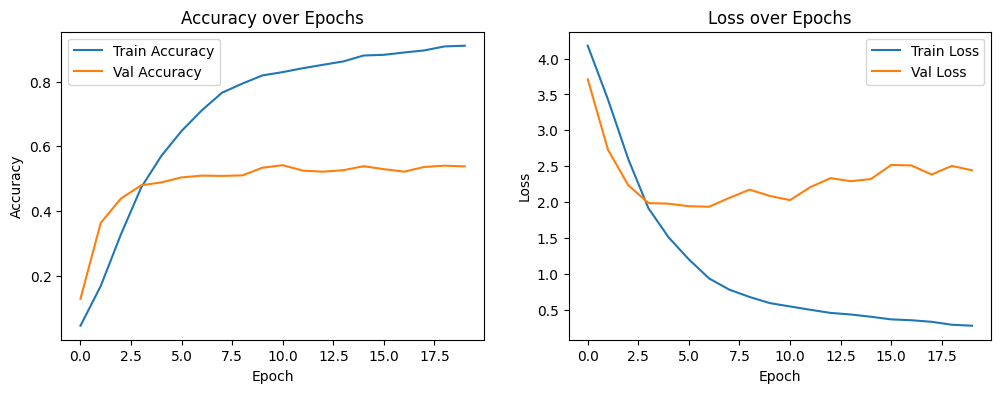

In [19]:
# Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(trainedModel.history["accuracy"], label="Train Accuracy")
plt.plot(trainedModel.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(trainedModel.history["loss"], label="Train Loss")
plt.plot(trainedModel.history["val_loss"], label="Val Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [20]:
val_loss, val_accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_accuracy:.2%}")
print(f"Validation Loss:     {val_loss:.4f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5377 - loss: 2.4424
Validation Accuracy: 53.77%
Validation Loss:     2.4424


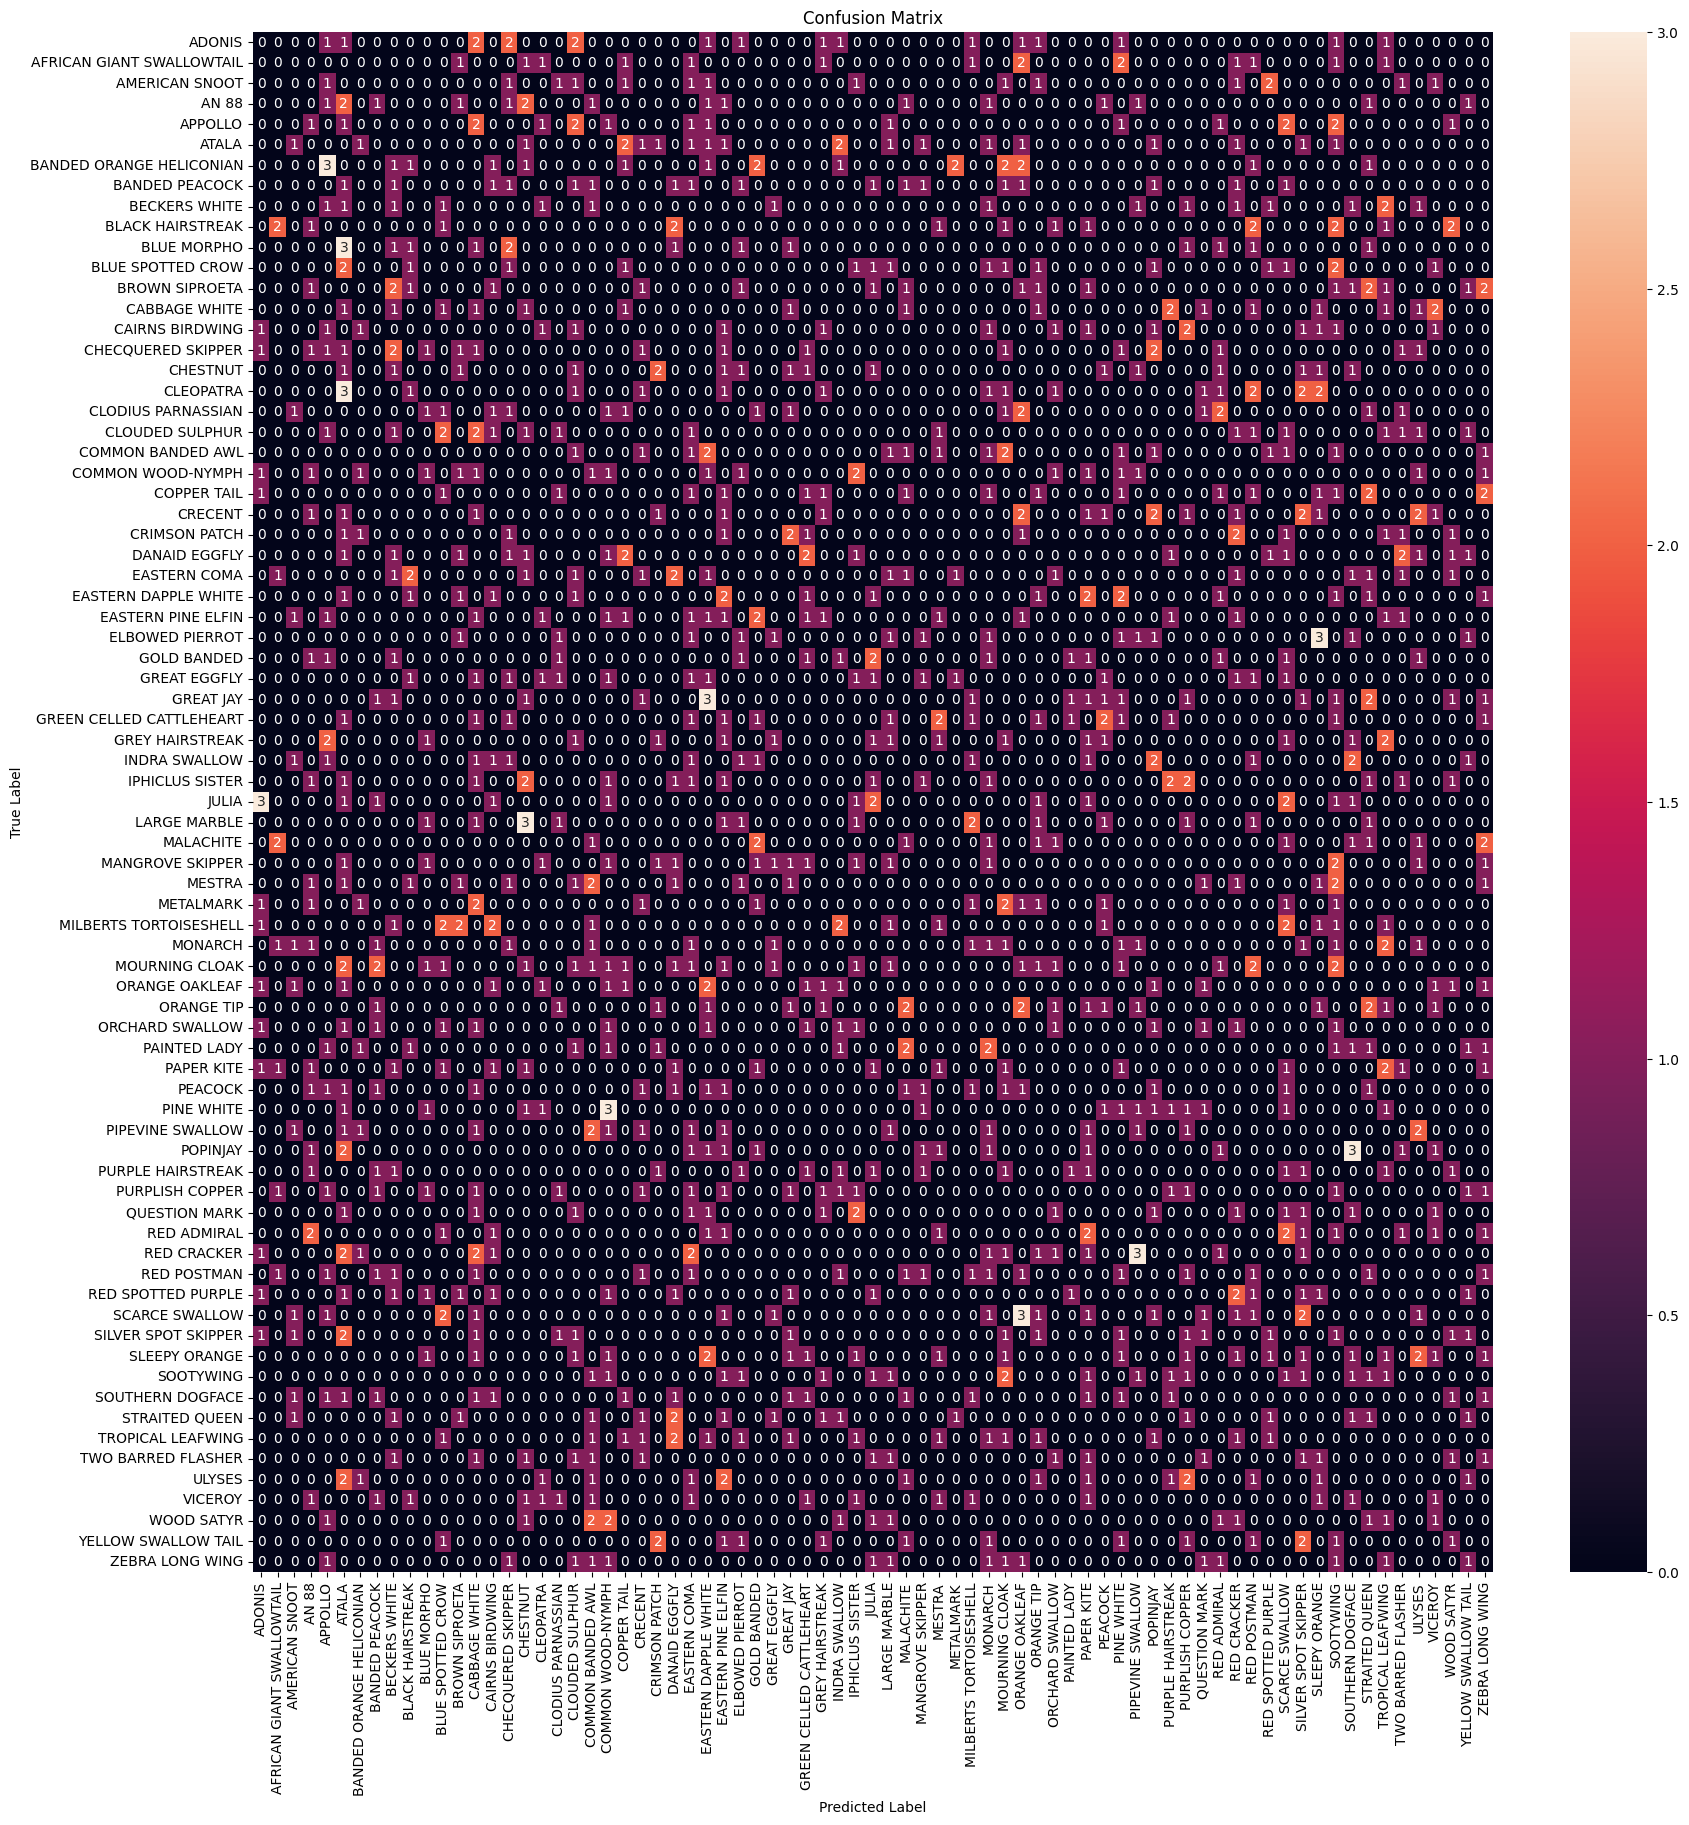

In [21]:
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_generator.class_indices.keys(),
            yticklabels=train_generator.class_indices.keys())
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()

In [22]:
img_size = (84, 84)
batch_size = 80

train_datagen2 = ImageDataGenerator(rescale=1.0 / 255)
val_datagen2   = ImageDataGenerator(rescale=1.0 / 255)
test_datagen2  = ImageDataGenerator(rescale=1.0 / 255)

train_generator2 = train_datagen2.flow_from_dataframe(
    dataframe=training_df,
    directory="train",
    x_col="filename",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

val_generator2 = val_datagen2.flow_from_dataframe(
    dataframe=validation_df,
    directory="train",
    x_col="filename",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

test_generator2 = test_datagen2.flow_from_dataframe(
    dataframe=testDataset,
    directory="test",
    x_col="filename",
    y_col=None,
    target_size=img_size,
    batch_size=batch_size,
    class_mode=None,
    shuffle=False
)

Found 5199 validated image filenames belonging to 75 classes.
Found 1300 validated image filenames belonging to 75 classes.
Found 2786 validated image filenames.


In [37]:
# Dictionary mapping each species to a number
# eg. {"ADONIS": 0, "MONARCH": 1, ...}
number_of_classes = len(train_generator2.class_indices)

# Building the model, Each block learns more complex features
# The activation function "relu" sets any negative values to zero
model2 = keras.Sequential([
    
    # Block 1
    layers.Conv2D(80, (3, 3), activation="relu", input_shape=(*img_size, 3)),
    layers.MaxPooling2D(2, 2),

    # Block 2
    layers.Conv2D(160, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    # Block 3
    layers.Conv2D(320, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    # Classifier head
    layers.Flatten(),
    layers.Dense(640, activation="relu"), # Takes all learned features and learns how to combine them
    layers.Dropout(0.7), # Reduces overfitting
    layers.Dense(number_of_classes, activation="softmax") # Outputs a probability score per species
])

model2.summary()

C:\Users\Diarmuid\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 82, 82, 80)          │           2,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 41, 41, 80)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 39, 39, 160)         │         115,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 19, 19, 160)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 17, 17, 320)         │         461,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 8, 8, 320)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 20480)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 640)                 │      13,107,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 640)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 75)                  │          48,075 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,734,635 (52.39 MB)

 Trainable params: 13,734,635 (52.39 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model2.compile(
    optimizer="adam", # Algorithm to adjust weights
    loss="categorical_crossentropy", # Loss function, measures how wrong a prediction is
    metrics=["accuracy"] # Metric that is tracked to track progress
)

In [39]:
earlyStopping=keras.callbacks.EarlyStopping(
    monitor="val_loss", # watch validation loss
    patience=5, # stop after 3 epochs of no improvement
    restore_best_weights=True # roll back to the best epoch's weights
)

trainedModel2=model2.fit(
    train_generator2,
    validation_data=val_generator2,
    epochs=30,
    callbacks=[earlyStopping]
)

Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 19s 288ms/step - accuracy: 0.0408 - loss: 4.1824 - val_accuracy: 0.1285 - val_loss: 3.5950
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 18s 281ms/step - accuracy: 0.1606 - loss: 3.3986 - val_accuracy: 0.3415 - val_loss: 2.6816
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 19s 292ms/step - accuracy: 0.2854 - loss: 2.7216 - val_accuracy: 0.4408 - val_loss: 2.1529
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 19s 288ms/step - accuracy: 0.4105 - loss: 2.2296 - val_accuracy: 0.5215 - val_loss: 1.8414
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 18s 281ms/step - accuracy: 0.4762 - loss: 1.9138 - val_accuracy: 0.5385 - val_loss: 1.7340
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 19s 285ms/step - accuracy: 0.5515 - loss: 1.6080 - val_accuracy: 0.5785 - val_loss: 1.5576
Epoch 7/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 19s 290ms/step - accuracy: 0.6188 - loss: 1.3344 - val_accuracy: 0.6200 - val_loss: 1.4273
Epoch 8/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 19s 292ms/step - accuracy: 0.6757 - loss: 1.1124 - val_accu

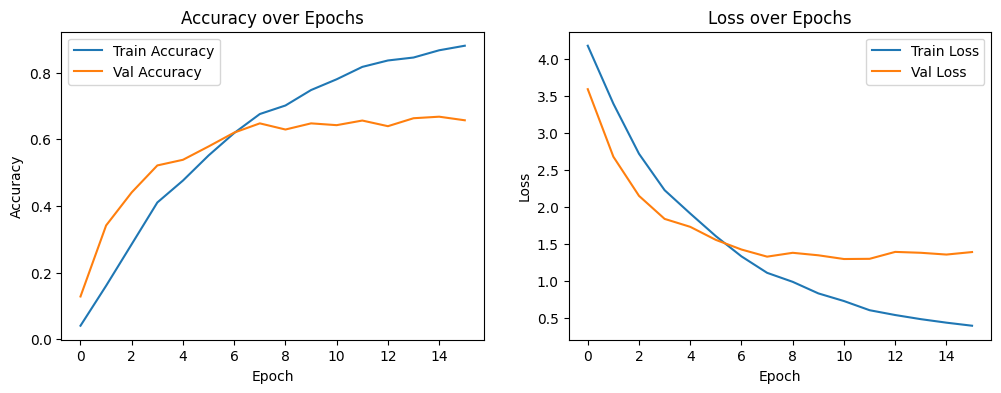

In [40]:
# Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(trainedModel2.history["accuracy"], label="Train Accuracy")
plt.plot(trainedModel2.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(trainedModel2.history["loss"], label="Train Loss")
plt.plot(trainedModel2.history["val_loss"], label="Val Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [41]:
val_loss2, val_accuracy2 = model2.evaluate(val_generator2)
print(f"Validation Accuracy: {val_accuracy2:.2%}")
print(f"Validation Loss:     {val_loss2:.4f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.6423 - loss: 1.2989
Validation Accuracy: 64.23%
Validation Loss:     1.2989


In [42]:
predictions2 = model2.predict(val_generator2)
predicted_indices2 = np.argmax(predictions2, axis=1)

index_to_class2 = {v: k for k, v in train_generator2.class_indices.items()}
predicted_labels2 = [index_to_class2[i] for i in predicted_indices2]

val_generator2.reset()
true_indices2 = val_generator2.classes
true_labels2 = [index_to_class2[i] for i in true_indices2]

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step


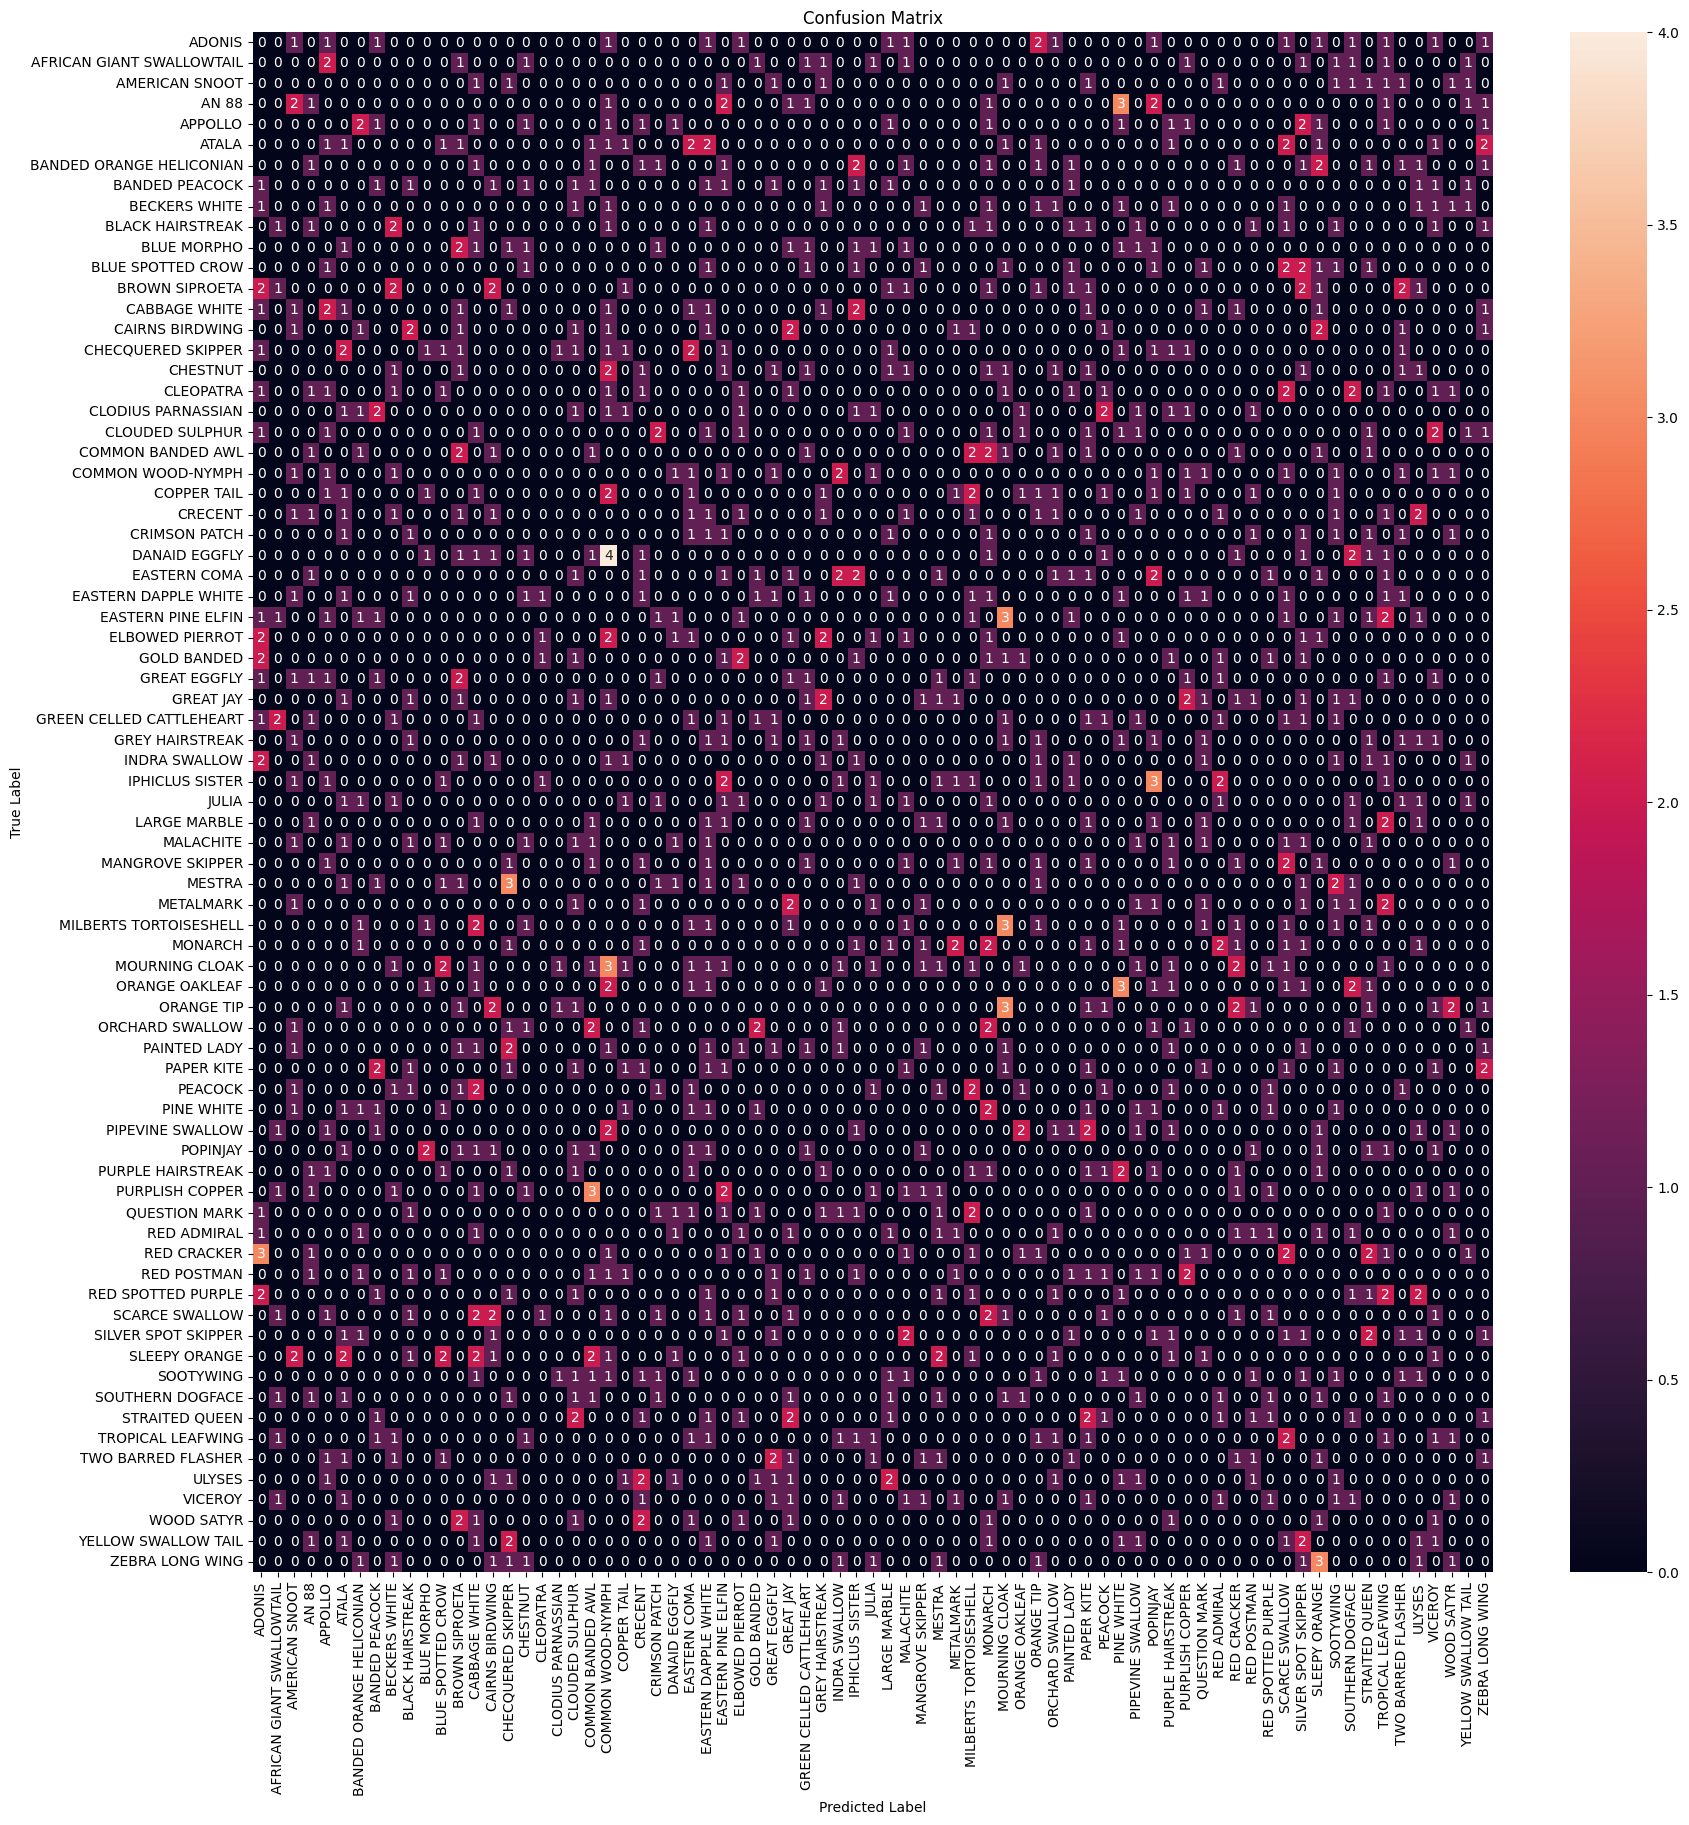

In [43]:
cm = confusion_matrix(true_labels2, predicted_labels2)
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_generator2.class_indices.keys(),
            yticklabels=train_generator2.class_indices.keys())
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()